In [102]:
##This is installing ggplot2 to create graphics
install.packages("ggplot2")
library(ggplot2)

In [103]:
##This is the data used
data <- read.csv("Methyl_Stearate_Use.csv")

In [104]:
##This was installed to help take averages of the data so that it could be graphed in a bar graph
install.packages("dplyr")
library(dplyr)

In [105]:
data <- data %>%
  mutate(interval = floor(Time))
##This rounded all of the time values down to the nearest second so that there were less catagories needed for the graph
avolt <- data2 %>%
  group_by(interval) %>%
  summarize(mean_voltage = mean(Voltage))
##This took the average of all the voltage readings in each 1 second interval 

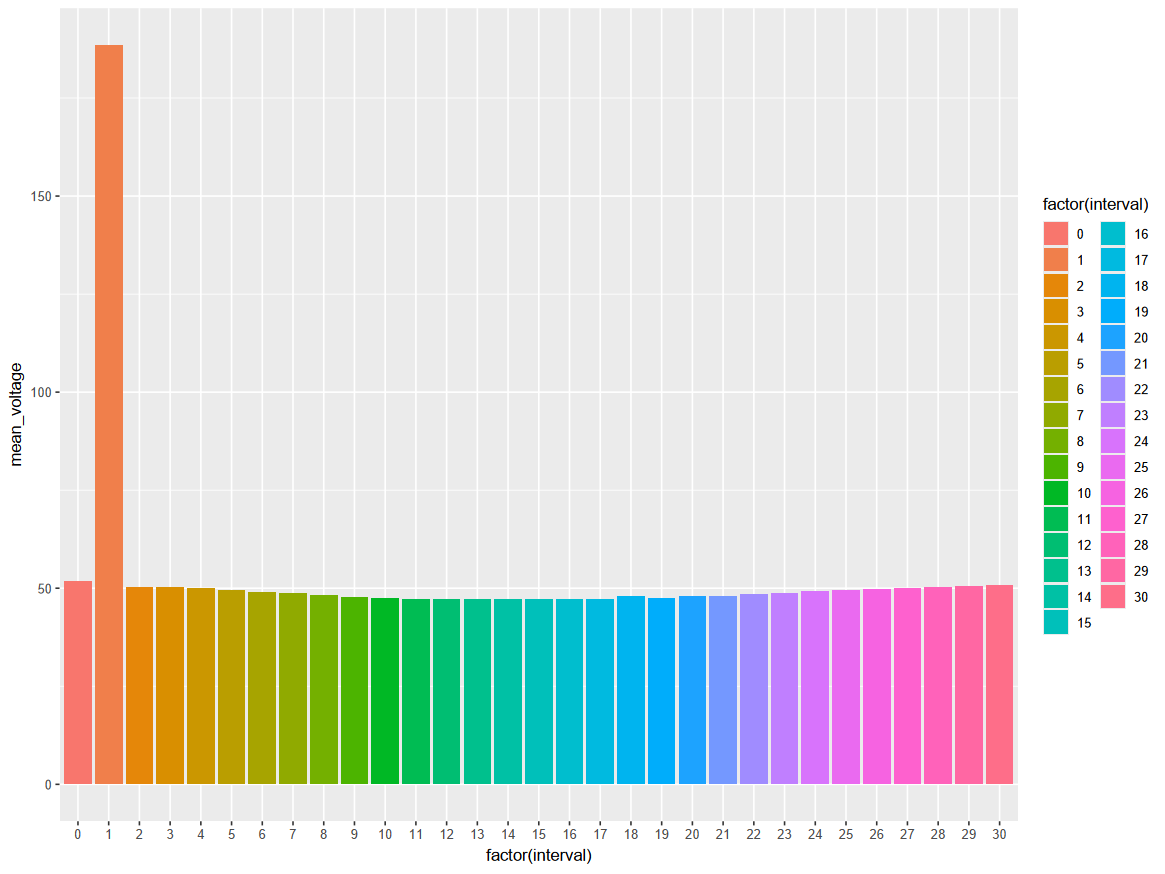

<ggplot2::labels> List of 3
 $ x   : chr "Time in Seconds"
 $ y   : chr "Average Voltage"
 $ fill: chr "Time in Seconds"

In [106]:
##This created a bar graph for the data using the average voltages and 1 second intervals.
ggplot(avolt, aes(x = factor(interval), y = mean_voltage, fill = factor(interval))) + 
  geom_col()
coord_flip ()
##This was done to put the time on the x axis
title = "Average Voltage in 1 Second Intervals for Methyl Stearate"
labs(x = "Time in Seconds", y = "Average Voltage", fill = "Time in Seconds")
##clarity for the graph

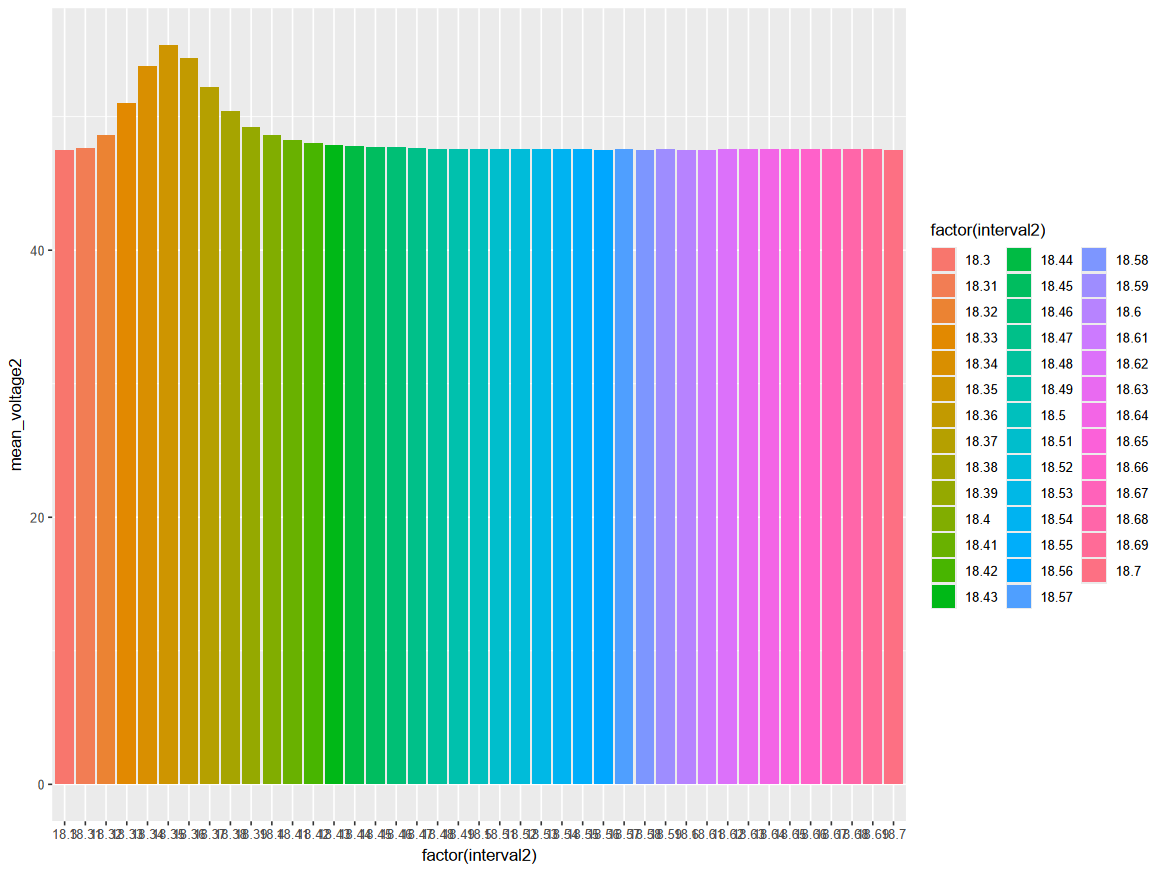

<ggplot2::labels> List of 3
 $ x   : chr "Time in Seconds"
 $ y   : chr "Average Voltage"
 $ fill: chr "Time in Seconds"

In [107]:
data <- data %>%
  mutate(interval2 = floor(Time * 100) / 100)
##splits the data into .01 second intervals
avolt2 <- data %>%
  group_by(interval2) %>%
  summarize(mean_voltage2 = mean(Voltage, na.rm = TRUE))
##averaging the voltage amounts in each interval

avolt2_subset <- avolt2 %>%
  filter(interval2 >= 18.3 & interval2 <= 18.7)
##Sets the values on the bottom of the graph to 18.2 to 18.8 seconds

ggplot(avolt2_subset, aes(x = factor(interval2), y = mean_voltage2, fill = factor(interval2))) + 
  geom_col()
##Graphing the zoomed in area

title = "Average Voltage in 1 Second Intervals for Methyl Stearate from 18.2 seconds to 18.8"
labs(x = "Time in Seconds", y = "Average Voltage", fill = "Time in Seconds")
##clarity for the graph

In [108]:
area_calculation <- avolt2_subset %>%
  arrange(interval2) %>% #this ensures the output value is positive
  mutate(dx = interval2 - lag(interval2), dy = (mean_voltage2 + lag(mean_voltage2)) / 2, trapezoid_area = dx * dy)
##dx is finding the difference between each .01 second interval between 18.3 and 18.7, because that is the interval of x in this avolt subset. dy is finding the difference between the corrisponding average voltage value for each x value, adding the two together, and dividng the two to find the average. dx and dy are then being multipied together. This is findng the area of each trapeziod.
area <- sum(area_calculation$trapezoid_area, na.rm = TRUE)
#This finds the total area of the trapezoids, which is the area under the curve.

print(area)

[1] 19.40644
